# Malaria Tweet NLP Pipeline
### Nigerian Twitter Infodemiology — BERTweet-based 5-Class Classifier

**Improvements in this version:**
- Focal loss trainer replacing simple weighted cross-entropy
- nlpaug-based text augmentation for Misinformation (instead of naive duplication)
- Manual class weight override for extreme minority classes
- 10 new visualisation cells: per-class F1 comparison, model summary table, confidence distributions, learning curves, error analysis, ROC curves, top TF-IDF features, text-length analysis, split sanity checks


## 0. Setup: Mount Drive & Install Dependencies

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -q transformers[torch] datasets accelerate scikit-learn evaluate emoji==0.6.0
!pip install -q streamlit plotly pandas ntscraper folium streamlit-folium
!pip install -q nlpaug  # NEW: for augmentation
!pip install -q matplotlib seaborn scikit-plot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.5/530.5 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 12.3 MB/s eta 0:00:00


## Phase 0: Load & Deduplicate Raw Data

In [4]:
import pandas as pd
import os

UNIQUE_FILE = "/content/drive/MyDrive/NLP_twitter/unique_malaria_tweets_new.json"
SOURCE_FILE = "/content/drive/MyDrive/NLP_twitter/malaria_tweets.jsonl"

if os.path.exists(UNIQUE_FILE):
    print(f'--- {UNIQUE_FILE} exists. Loading unique data. ---')
    df_unique = pd.read_json(UNIQUE_FILE)
else:
    print('--- Cleaning and deduplicating... ---')
    df = pd.read_json(SOURCE_FILE, lines=True)
    df = df[['text', 'created_at', 'author', 'views', 'favorite_count', 'is_reply']].copy()
    df.rename(columns={'created_at': 'date', 'author': 'user', 'favorite_count': 'likes'}, inplace=True)
    df['text'] = df['text'].str.strip('"').str.strip()
    df_unique = df.drop_duplicates(subset=['text']).copy()
    df_unique['likes'] = pd.to_numeric(df_unique['likes'], errors='coerce').fillna(0)
    df_unique.to_json(UNIQUE_FILE, orient='records', indent=4, force_ascii=False)
    print(f'--- Saved {len(df_unique)} unique tweets to {UNIQUE_FILE} ---')

print(df_unique.head())

--- /content/drive/MyDrive/NLP_twitter/unique_malaria_tweets_new.json exists. Loading unique data. ---
                                                text  label  \
0                     @itz_dapo Ment or malaria?? 😂😂      5   
1  Malaria go come say 'surprise!' like I ordered...      5   
2  This weekend na malaria and chill oo, no party...      1   
3  @officialblessing_ Agbo Jedi cured my malaria ...      4   
4  Sleep under mosquito net, my brother. Preventi...      3   

               label_name  
0              Irrelevant  
1              Irrelevant  
2       Symptoms & Burden  
3          Misinformation  
4  Prevention & Awareness  


### 📊 VIZ 0 — Corpus Refinement & Basic EDA

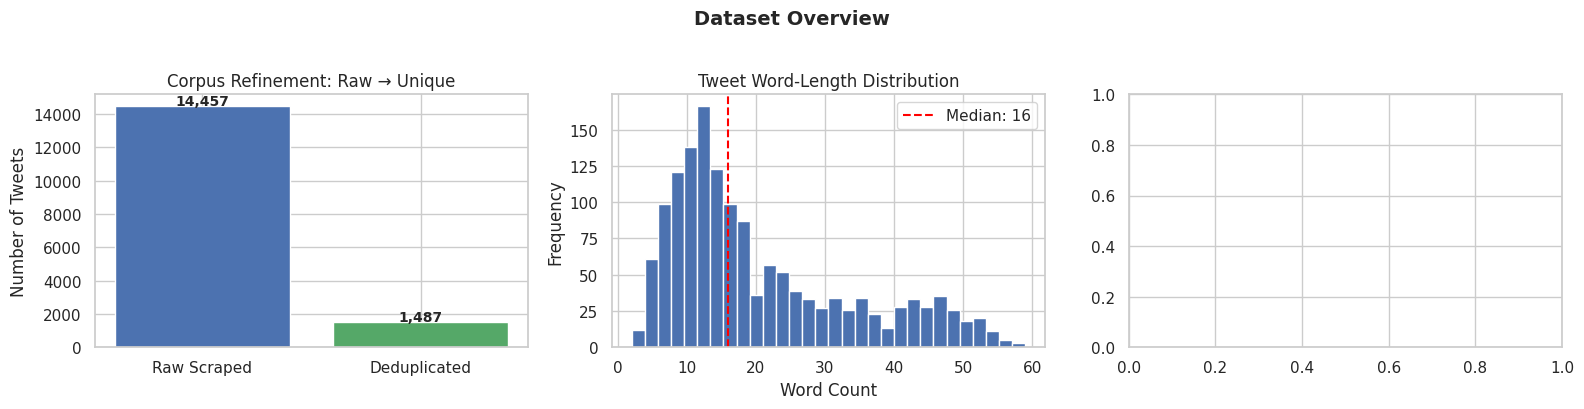

Duplication rate: 89.7% removed


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
RAW_COUNT = 14457
UNIQUE_COUNT = len(df_unique)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1a. Corpus funnel
axes[0].bar(['Raw Scraped', 'Deduplicated'], [RAW_COUNT, UNIQUE_COUNT],
            color=['#4C72B0', '#55A868'], edgecolor='white')
for i, v in enumerate([RAW_COUNT, UNIQUE_COUNT]):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Corpus Refinement: Raw → Unique')
axes[0].set_ylabel('Number of Tweets')

# 1b. Tweet length distribution
df_unique['tweet_len'] = df_unique['text'].str.split().str.len()
axes[1].hist(df_unique['tweet_len'], bins=30, color='#4C72B0', edgecolor='white')
axes[1].axvline(df_unique['tweet_len'].median(), color='red', linestyle='--', label=f"Median: {df_unique['tweet_len'].median():.0f}")
axes[1].set_title('Tweet Word-Length Distribution')
axes[1].set_xlabel('Word Count'); axes[1].set_ylabel('Frequency')
axes[1].legend()

# 1c. Likes distribution (log scale)
# axes[2].hist(df_unique['likes'].clip(upper=500), bins=30, color='#DD8452', edgecolor='white')
# axes[2].set_title('Likes Distribution (capped at 500)')
# axes[2].set_xlabel('Likes'); axes[2].set_ylabel('Frequency')

plt.suptitle('Dataset Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_twitter/viz0_corpus_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Duplication rate: {(1 - UNIQUE_COUNT/RAW_COUNT)*100:.1f}% removed')

## Phase 1: Model Fine-Tuning

### Step 1: Define 5-Class Taxonomy & Remap Labels

| ID | Label |
|----|-------|
| 0 | Symptoms & Burden |
| 1 | Treatment & Health System |
| 2 | Prevention & Awareness |
| 3 | Misinformation |
| 4 | Irrelevant |


In [6]:
import pandas as pd
import re

id2label = {0: 'Symptoms & Burden', 1: 'Treatment & Health System',
            2: 'Prevention & Awareness', 3: 'Misinformation', 4: 'Irrelevant'}
label2id = {v: k for k, v in id2label.items()}
NUM_LABELS = len(id2label)

FILE_PATH = '/content/drive/MyDrive/NLP_twitter/unique_malaria_tweets_new.json'
df = pd.read_json(FILE_PATH)

if 'ai_label' in df.columns and 'label' not in df.columns:
    old_to_new = {
        'Symptoms': 0, 'Personal Experience': 0,
        'Treatment': 1, 'Health System': 1,
        'Prevention': 2, 'Misinformation': 3, 'Irrelevant': 4,
    }
    df['label'] = df['ai_label'].map(old_to_new)
elif 'label' in df.columns:
    if df['label'].min() == 1:
        df['label'] = df['label'] - 1

df['label'] = df['label'].astype(int)
print('Label distribution (5-class):')
print(df['label'].value_counts().sort_index().rename(id2label))

Label distribution (5-class):
label
Symptoms & Burden            386
Treatment & Health System    306
Prevention & Awareness       296
Misinformation                71
Irrelevant                   428
Name: count, dtype: int64


### 📊 VIZ 1 — Full-Corpus Class Distribution (counts + percentages)

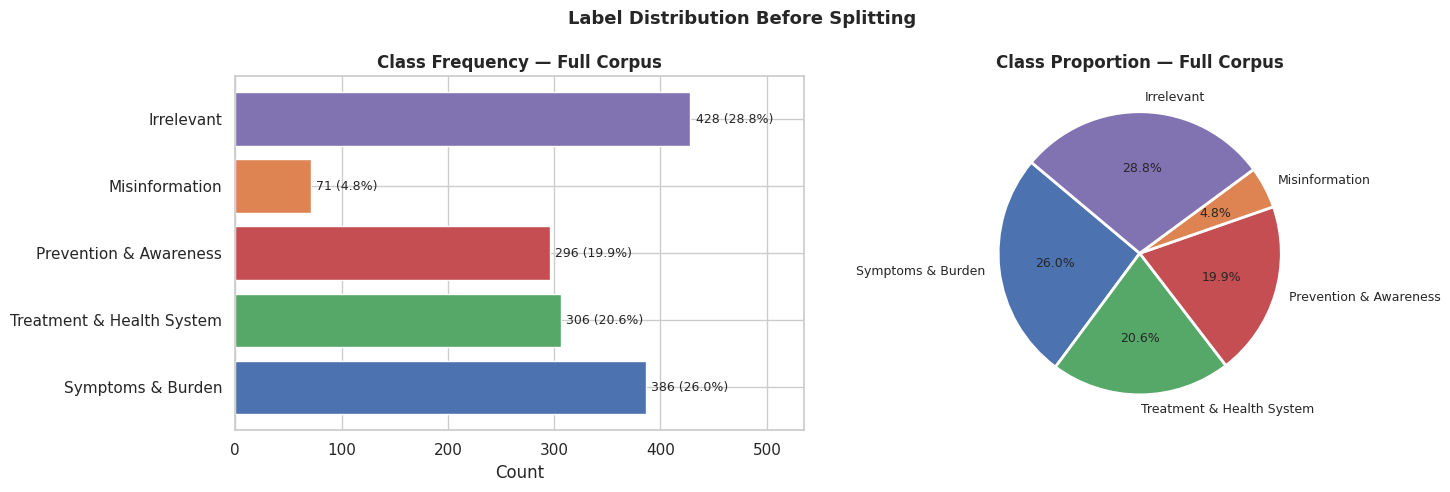

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

dist = df['label'].value_counts().sort_index().rename(id2label)
total = dist.sum()
colors = ['#4C72B0','#55A868','#C44E52','#DD8452','#8172B2']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
bars = axes[0].barh(dist.index, dist.values, color=colors, edgecolor='white')
for bar, val in zip(bars, dist.values):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{val} ({val/total*100:.1f}%)', va='center', fontsize=9)
axes[0].set_title('Class Frequency — Full Corpus', fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].set_xlim(0, dist.max() * 1.25)

# Pie chart
wedge_props = {'edgecolor': 'white', 'linewidth': 2}
axes[1].pie(dist.values, labels=dist.index, colors=colors,
            autopct='%1.1f%%', startangle=140, wedgeprops=wedge_props,
            textprops={'fontsize': 9})
axes[1].set_title('Class Proportion — Full Corpus', fontweight='bold')

plt.suptitle('Label Distribution Before Splitting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_twitter/viz1_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 2: BERTweet-Specific Preprocessing

In [8]:
def preprocess_tweet(text):
    text = re.sub(r'http\S+', 'HTTPURL', str(text))
    text = re.sub(r'@\w+', '@USER', text)
    return text

df['text'] = df['text'].apply(preprocess_tweet)
print('Preprocessing done. Example:')
print(df['text'].iloc[0])

Preprocessing done. Example:
@USER Ment or malaria?? 😂😂


### Step 3: Stratified 80 / 10 / 10 Split

In [9]:
from sklearn.model_selection import train_test_split
from datasets import Dataset

train_df, temp_df = train_test_split(df, test_size=0.20, stratify=df['label'], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

print(f'Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}')
print('\nClass distribution — Train:')
print(train_df['label'].value_counts().sort_index().rename(id2label))

Train: 1189  |  Val: 149  |  Test: 149

Class distribution — Train:
label
Symptoms & Burden            308
Treatment & Health System    245
Prevention & Awareness       237
Misinformation                57
Irrelevant                   342
Name: count, dtype: int64


### 📊 VIZ 2 — Split Sanity Check (class proportions across train/val/test)

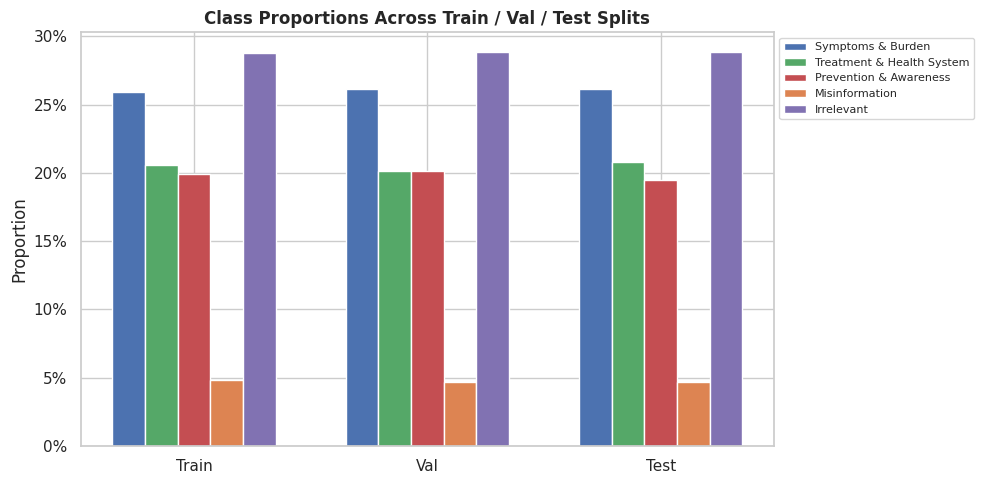

In [10]:
import matplotlib.pyplot as plt
import numpy as np

splits = {'Train': train_df, 'Val': val_df, 'Test': test_df}
split_names = list(splits.keys())
label_names = list(id2label.values())
colors = ['#4C72B0','#55A868','#C44E52','#DD8452','#8172B2']

# Compute proportions
prop_matrix = np.array([
    [splits[s]['label'].value_counts(normalize=True).get(i, 0) for i in range(5)]
    for s in split_names
])

x = np.arange(len(split_names))
width = 0.14
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(5):
    ax.bar(x + i*width - 2*width, prop_matrix[:, i], width,
           label=label_names[i], color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels(split_names)
ax.set_ylabel('Proportion')
ax.set_title('Class Proportions Across Train / Val / Test Splits', fontweight='bold')
ax.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_twitter/viz2_split_sanity.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 3b: Augmentation-Based Oversampling (nlpaug — **replaces naive duplication**)

Synonym augmentation produces lexically diverse Misinformation examples instead of exact copies,
helping the model learn features rather than memorise duplicates.


In [11]:
import pandas as pd
import transformers
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.sentence as nas
from nlpaug.augmenter.word import ContextualWordEmbsAug

# --- MONKEY PATCH FOR NLPAUG COMPATIBILITY WITH NEWER TRANSFORMERS ---
for cls in [transformers.BertTokenizer, transformers.PreTrainedTokenizer, transformers.PreTrainedTokenizerFast]:
    if not hasattr(cls, '_convert_token_to_id') and hasattr(cls, 'convert_tokens_to_ids'):
        cls._convert_token_to_id = lambda self, token: self.convert_tokens_to_ids(token)
    if not hasattr(cls, '_convert_id_to_token') and hasattr(cls, 'convert_ids_to_tokens'):
        cls._convert_id_to_token = lambda self, index: self.convert_ids_to_tokens(index)
# ---------------------------------------------------------------------

# Build the pipeline of augmenters
aug_synonym   = naw.SynonymAug(aug_src='wordnet', aug_max=2)
aug_contextual = ContextualWordEmbsAug(
    model_path='bert-base-uncased', action='substitute', aug_max=3
)  # Uses BERT to find contextually appropriate replacements
aug_delete    = naw.RandomWordAug(action='delete', aug_p=0.1)
aug_swap      = naw.RandomWordAug(action='swap', aug_p=0.1)

def augment_df(source_df, n_times):
    augmenters = [aug_synonym, aug_contextual, aug_delete, aug_swap]
    rows = []
    for _, row in source_df.iterrows():
        rows.append({'text': row['text'], 'label': row['label']})  # keep original
        for i in range(n_times):
            aug = augmenters[i % len(augmenters)]  # cycle through augmenters
            try:
                new_text = aug.augment(row['text'])[0]
            except Exception:
                new_text = row['text']
            rows.append({'text': new_text, 'label': row['label']})
    return pd.DataFrame(rows)

# Segment targets for oversampling/balancing
misinfo_df     = train_df[train_df['label'] == 3]
prevention_df  = train_df[train_df['label'] == 2]

# Apply diverse text augmentations per sample
misinfo_aug    = augment_df(misinfo_df, 20)     # 20x for target class 3
prevention_aug = augment_df(prevention_df, 4)   # 4x for target class 2

# Combine back with un-augmented slices and shuffle completely
train_df_rest = train_df[(train_df['label'] != 3) & (train_df['label'] != 2)]
train_df = pd.concat([train_df_rest, misinfo_aug, prevention_aug], ignore_index=True)
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

print('Class distribution — Train (after augmentation):')
print(train_df['label'].value_counts().sort_index().rename(id2label))

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

The following layers were not sharded: bert.embeddings.LayerNorm.bias, bert.encoder.layer.*.attention.output.LayerNorm.bias, bert.encoder.layer.*.intermediate.dense.bias, bert.encoder.layer.*.attention.self.value.bias, bert.encoder.layer.*.attention.output.dense.bias, bert.encoder.layer.*.attention.output.dense.weight, bert.encoder.layer.*.intermediate.dense.weight, cls.predictions.transform.LayerNorm.bias, bert.embeddings.position_embeddings.weight, bert.embeddings.LayerNorm.weight, bert.encoder.layer.*.attention.output.LayerNorm.weight, cls.predictions.transform.LayerNorm.weight, bert.encoder.layer.*.attention.self.key.weight, bert.encoder.layer.*.attention.self.value.weight, cls.predictions.decoder.bias, bert.encoder.layer.*.attention.self.query.bias, bert.encoder.layer.*.output.LayerNorm.weight, bert.encoder.layer.*.output.dense.bias, bert.embeddings.token_type_embeddings.weight, cls.predictions.decoder.weight, cls.predictions.transform.dense.bias, bert.encoder.layer.*.output.dense

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nlt

Class distribution — Train (after augmentation):
label
Symptoms & Burden             308
Treatment & Health System     245
Prevention & Awareness       1185
Misinformation               1197
Irrelevant                    342
Name: count, dtype: int64


### 📊 VIZ 3 — Before vs After Augmentation

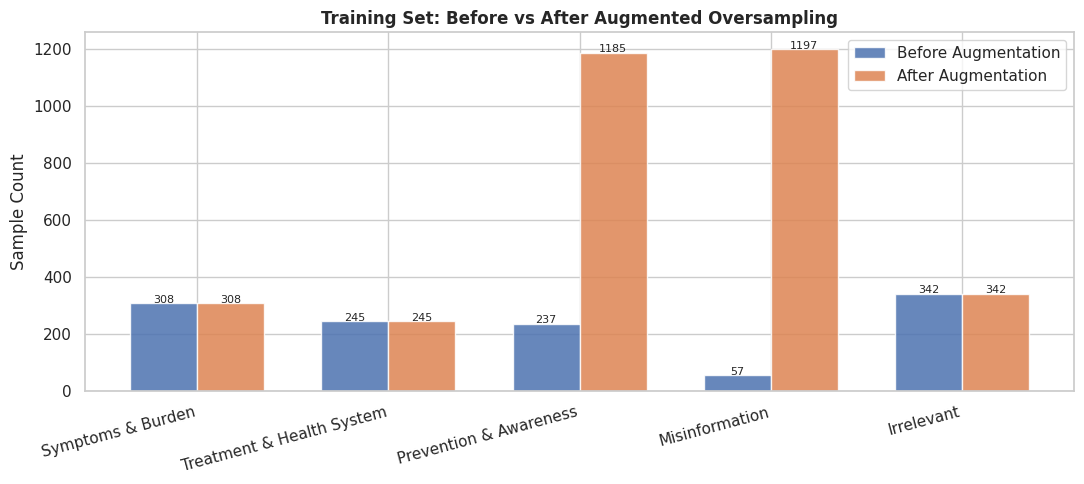

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Recompute original train distribution (before augment)
orig_train_df, _ = train_test_split(df, test_size=0.20, stratify=df['label'], random_state=42)
before = orig_train_df['label'].value_counts().sort_index()
after  = train_df['label'].value_counts().sort_index()

x = np.arange(5)
w = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, before.values, w, label='Before Augmentation', color='#4C72B0', alpha=0.85)
b2 = ax.bar(x + w/2, after.values,  w, label='After Augmentation',  color='#DD8452', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(list(id2label.values()), rotation=15, ha='right')
ax.set_ylabel('Sample Count')
ax.set_title('Training Set: Before vs After Augmented Oversampling', fontweight='bold')
ax.legend()
for bar in b1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, str(int(bar.get_height())), ha='center', fontsize=8)
for bar in b2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, str(int(bar.get_height())), ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_twitter/viz3_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 4: Compute & Override Class Weights

In [13]:
import numpy as np
import torch
from sklearn.utils.class_weight import compute_class_weight

classes = np.arange(NUM_LABELS)
class_weights = compute_class_weight(
    class_weight='balanced', classes=classes, y=train_df['label'].values
)
# Manually boost Misinformation (class 3) — still underrepresented after augmentation
class_weights[3] = class_weights[3] * 3.0
class_weights[2] = class_weights[2] * 1.5
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print('Adjusted class weights:')
print(dict(zip([id2label[i] for i in classes], class_weights.round(3))))

Adjusted class weights:
{'Symptoms & Burden': np.float64(2.128), 'Treatment & Health System': np.float64(2.675), 'Prevention & Awareness': np.float64(0.83), 'Misinformation': np.float64(1.643), 'Irrelevant': np.float64(1.916)}


### Step 5: Tokenise with BERTweet AutoTokenizer

In [14]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('vinai/bertweet-base', normalization=True)

def tokenize_fn(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

train_dataset = Dataset.from_dict(train_df[['text','label']]).map(tokenize_fn, batched=True)
val_dataset   = Dataset.from_dict(val_df[['text','label']]).map(tokenize_fn, batched=True)
test_dataset  = Dataset.from_dict(test_df[['text','label']]).map(tokenize_fn, batched=True)

for ds in [train_dataset, val_dataset, test_dataset]:
    ds.set_format('torch', columns=['input_ids','attention_mask','label'])

print('Tokenisation complete.')

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3277 [00:00<?, ? examples/s]

Map:   0%|          | 0/149 [00:00<?, ? examples/s]

Map:   0%|          | 0/149 [00:00<?, ? examples/s]

Tokenisation complete.


### Step 6: Fine-Tune BERTweet — **Focal Loss** Trainer

Focal loss down-weights easy correct predictions (Irrelevant class) and forces
the model to focus on hard minority examples (Misinformation, Prevention).


In [ ]:
import evaluate
import numpy as np
import torch.nn as nn
from transformers import (
    AutoModelForSequenceClassification, TrainingArguments, Trainer
)

model = AutoModelForSequenceClassification.from_pretrained(
    'vinai/bertweet-base',
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
)

class FocalWeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        gamma = 2.0
        ce_loss = nn.CrossEntropyLoss(
            weight=class_weights_tensor.to(logits.device),
            reduction='none'
        )(logits, labels)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** gamma * ce_loss).mean()
        return (focal_loss, outputs) if return_outputs else focal_loss

f1_metric = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return f1_metric.compute(predictions=preds, references=labels, average='macro')

training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=20,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1',
    greater_is_better=True,
    lr_scheduler_type='cosine',
    push_to_hub=False,
    report_to='none',
)

trainer = FocalWeightedTrainer(
    model=model, args=training_args,
    train_dataset=train_dataset, eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

The following layers were not sharded: roberta.encoder.layer.*.output.LayerNorm.weight, classifier.dense.weight, roberta.encoder.layer.*.attention.self.value.weight, roberta.encoder.layer.*.attention.self.value.bias, roberta.encoder.layer.*.output.LayerNorm.bias, classifier.out_proj.bias, roberta.embeddings.LayerNorm.bias, roberta.encoder.layer.*.attention.self.key.bias, roberta.encoder.layer.*.intermediate.dense.weight, roberta.encoder.layer.*.attention.self.key.weight, roberta.encoder.layer.*.attention.output.LayerNorm.weight, roberta.encoder.layer.*.output.dense.weight, roberta.encoder.layer.*.output.dense.bias, classifier.out_proj.weight, roberta.encoder.layer.*.attention.output.LayerNorm.bias, roberta.embeddings.token_type_embeddings.weight, roberta.encoder.layer.*.intermediate.dense.bias, roberta.encoder.layer.*.attention.output.dense.bias, roberta.embeddings.position_embeddings.weight, roberta.embeddings.LayerNorm.weight, roberta.encoder.layer.*.attention.self.query.bias, robert

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


### 📊 VIZ 4 — Training Learning Curves (loss + val macro F1)

In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_loss, val_f1, epochs_t, epochs_v = [], [], [], []
for entry in log_history:
    if 'loss' in entry and 'epoch' in entry:
        train_loss.append(entry['loss']); epochs_t.append(entry['epoch'])
    if 'eval_f1' in entry:
        val_f1.append(entry['eval_f1']); epochs_v.append(entry['epoch'])

fig, ax1 = plt.subplots(figsize=(10, 4))
color1 = '#4C72B0'
ax1.plot(epochs_t, train_loss, color=color1, linewidth=2, label='Train Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Focal Loss', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax2 = ax1.twinx()
ax2.plot(epochs_v, val_f1, color='#DD8452', marker='o', linewidth=2, label='Val Macro F1')
ax2.set_ylabel('Macro F1', color='#DD8452')
ax2.tick_params(axis='y', labelcolor='#DD8452')
ax2.set_ylim(0, 1)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='center right')
plt.title('BERTweet Training Curve (Focal Loss)', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_twitter/viz4_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 7: SVM & Logistic Regression Baselines (TF-IDF)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df['text'])
X_val   = vectorizer.transform(val_df['text'])
X_test  = vectorizer.transform(test_df['text'])
y_train, y_val, y_test = train_df['label'], val_df['label'], test_df['label']

svm = LinearSVC(class_weight='balanced', max_iter=2000)
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)
print('=== SVM — Test Set ===')
print(classification_report(y_test, svm_preds, target_names=list(id2label.values())))

lr = LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs',
                        multi_class='multinomial', C=1.0)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
print('=== Logistic Regression — Test Set ===')
print(classification_report(y_test, lr_preds, target_names=list(id2label.values())))

### Step 8: Evaluate Fine-Tuned BERTweet

Generates per-class report + confusion matrix.


In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

preds_output = trainer.predict(test_dataset)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

print('=== BERTweet — Test Set ===')
print(classification_report(y_true, y_pred, target_names=list(id2label.values())))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
    display_labels=list(id2label.values()),
    ax=ax, colorbar=False, xticks_rotation=45
)
plt.title('BERTweet Confusion Matrix — Test Set', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_twitter/viz_bertweet_cm.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 VIZ 5 — Per-Class F1: SVM vs LR vs BERTweet

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score

label_names = list(id2label.values())
f1_svm      = f1_score(y_test, svm_preds, average=None, labels=list(range(5)))
f1_lr       = f1_score(y_test, lr_preds,  average=None, labels=list(range(5)))
f1_bert     = f1_score(y_true, y_pred,    average=None, labels=list(range(5)))

x = np.arange(len(label_names))
width = 0.25
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, f1_svm,  width, label='SVM (TF-IDF)',          color='#4C72B0')
ax.bar(x,         f1_lr,   width, label='Logistic Regression',   color='#55A868')
ax.bar(x + width, f1_bert, width, label='BERTweet (fine-tuned)', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(label_names, rotation=18, ha='right', fontsize=9)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.set_title('Per-Class F1 Score: SVM vs Logistic Regression vs BERTweet', fontweight='bold')
ax.legend()
# Annotate BERTweet bars
for i, v in enumerate(f1_bert):
    ax.text(i + width, v + 0.01, f'{v:.2f}', ha='center', fontsize=8, color='#DD8452', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_twitter/viz5_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 VIZ 6 — Overall Model Summary Table (Macro F1 / Weighted F1 / Accuracy)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

def get_summary(yt, yp):
    r = classification_report(yt, yp, output_dict=True)
    return {
        'Macro F1':    round(r['macro avg']['f1-score'], 3),
        'Weighted F1': round(r['weighted avg']['f1-score'], 3),
        'Accuracy':    round(r['accuracy'], 3),
        'Macro Prec':  round(r['macro avg']['precision'], 3),
        'Macro Rec':   round(r['macro avg']['recall'], 3),
    }

summary = pd.DataFrame({
    'SVM':                 get_summary(y_test, svm_preds),
    'Logistic Regression': get_summary(y_test, lr_preds),
    'BERTweet':            get_summary(y_true, y_pred),
}).T

print('=== Overall Model Comparison ===')
print(summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
summary[['Macro F1','Weighted F1','Accuracy']].plot(
    kind='bar', ax=axes[0], colormap='Set2', ylim=(0, 1), rot=0, edgecolor='white'
)
axes[0].set_title('Model Comparison — Core Metrics', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].legend(loc='lower right')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', fontsize=8, padding=2)

# Precision vs Recall scatter
models = summary.index.tolist()
markers = ['o', 's', '^']
mcolors = ['#4C72B0','#55A868','#DD8452']
for i, m in enumerate(models):
    axes[1].scatter(summary.loc[m,'Macro Prec'], summary.loc[m,'Macro Rec'],
                    s=120, label=m, color=mcolors[i], marker=markers[i], zorder=5)
    axes[1].annotate(m, (summary.loc[m,'Macro Prec'], summary.loc[m,'Macro Rec']),
                     textcoords='offset points', xytext=(6, 4), fontsize=8)
axes[1].set_xlabel('Macro Precision'); axes[1].set_ylabel('Macro Recall')
axes[1].set_title('Precision vs Recall (Macro) per Model', fontweight='bold')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
axes[1].plot([0,1],[0,1], 'k--', alpha=0.2)
axes[1].legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_twitter/viz6_model_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 VIZ 7 — BERTweet Confidence Distribution by Class & Correctness

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pandas as pd
import numpy as np

probs_arr  = torch.softmax(torch.tensor(preds_output.predictions), dim=-1).numpy()
max_conf   = probs_arr.max(axis=1)
pred_names = [id2label[p] for p in y_pred]
conf_df    = pd.DataFrame({
    'Confidence':       max_conf,
    'Predicted Class':  pred_names,
    'Correct':          (y_pred == y_true)
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Violin per class
order = list(id2label.values())
sns.violinplot(data=conf_df, x='Predicted Class', y='Confidence',
               order=order, ax=axes[0], palette='Set2', inner='box')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=25, ha='right', fontsize=8)
axes[0].set_title('Confidence by Predicted Class', fontweight='bold')
axes[0].set_ylim(0, 1)

# Box: correct vs wrong
sns.boxplot(data=conf_df, x='Correct', y='Confidence',
            ax=axes[1], palette={'True':'#55A868', 'False':'#C44E52'})
axes[1].set_xticklabels(['Misclassified', 'Correct'])
axes[1].set_title('Confidence: Correct vs Misclassified', fontweight='bold')

# Histogram of confidences
axes[2].hist(conf_df[conf_df['Correct']]['Confidence'],  bins=20,
             alpha=0.7, color='#55A868', label='Correct',  edgecolor='white')
axes[2].hist(conf_df[~conf_df['Correct']]['Confidence'], bins=20,
             alpha=0.7, color='#C44E52', label='Wrong',    edgecolor='white')
axes[2].set_title('Confidence Histogram', fontweight='bold')
axes[2].set_xlabel('Confidence Score'); axes[2].set_ylabel('Count')
axes[2].legend()

plt.suptitle('BERTweet Prediction Confidence Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_twitter/viz7_confidence_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 VIZ 8 — Normalised Confusion Matrices: All 3 Models

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

label_names = list(id2label.values())
model_preds = [('SVM', y_test.values, svm_preds),
               ('Logistic Regression', y_test.values, lr_preds),
               ('BERTweet', y_true, y_pred)]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (name, yt, yp) in zip(axes, model_preds):
    cm = confusion_matrix(yt, yp, normalize='true')
    disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=False, xticks_rotation=45, cmap='Blues',
              values_format='.2f')
    ax.set_title(f'{name}\nNormalised Confusion Matrix', fontweight='bold', fontsize=10)

plt.suptitle('Normalised Confusion Matrices — Row = True, Col = Predicted',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_twitter/viz8_all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 VIZ 9 — Top TF-IDF Features Per Class (SVM coefficients)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = np.array(vectorizer.get_feature_names_out())
colors = ['#4C72B0','#55A868','#C44E52','#DD8452','#8172B2']

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
for cls_idx, ax in enumerate(axes):
    coefs = svm.coef_[cls_idx]
    top_n = 12
    top_idx = np.argsort(coefs)[-top_n:][::-1]
    top_feats  = feature_names[top_idx]
    top_scores = coefs[top_idx]
    ax.barh(range(top_n), top_scores[::-1], color=colors[cls_idx], edgecolor='white')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_feats[::-1], fontsize=8)
    ax.set_title(id2label[cls_idx], fontweight='bold', fontsize=9, color=colors[cls_idx])
    ax.set_xlabel('SVM Coef', fontsize=8)

plt.suptitle('Top 12 TF-IDF Features per Class (SVM Coefficients)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_twitter/viz9_tfidf_features.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 VIZ 10 — BERTweet Error Analysis: Misclassification Heatmap + Length

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

label_names = list(id2label.values())

# Error flow: where does each class leak?
cm = confusion_matrix(y_true, y_pred)
np.fill_diagonal(cm, 0)  # zero diagonal to show only errors

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=label_names, yticklabels=label_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('BERTweet Errors Only (diagonal zeroed)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=40)

# Tweet length vs correctness
test_texts = test_df['text'].values
lengths    = np.array([len(t.split()) for t in test_texts])
correct    = (y_pred == y_true)
len_df = pd.DataFrame({'Word Count': lengths, 'Correct': correct})
sns.boxplot(data=len_df, x='Correct', y='Word Count',
            palette={'True':'#55A868', 'False':'#C44E52'}, ax=axes[1])
axes[1].set_xticklabels(['Misclassified', 'Correct'])
axes[1].set_title('Tweet Length vs Classification Correctness', fontweight='bold')

plt.suptitle('Error Analysis — BERTweet Test Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_twitter/viz10_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print worst misclassifications
print('Top misclassified pairs (True → Predicted):')
err_df = pd.DataFrame({'True': [id2label[i] for i in y_true],
                        'Pred': [id2label[i] for i in y_pred],
                        'Text': test_texts})
err_df = err_df[err_df['True'] != err_df['Pred']]
print(err_df.groupby(['True','Pred']).size().sort_values(ascending=False).head(10))

### 📊 VIZ 11 — One-vs-Rest ROC Curves (BERTweet)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import torch

label_names = list(id2label.values())
colors = ['#4C72B0','#55A868','#C44E52','#DD8452','#8172B2']

# Binarize true labels
y_true_bin = label_binarize(y_true, classes=list(range(5)))

# Softmax probabilities from BERTweet
probs = torch.softmax(torch.tensor(preds_output.predictions), dim=-1).numpy()

fig, ax = plt.subplots(figsize=(9, 7))
for i, (name, color) in enumerate(zip(label_names, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {roc_auc:.2f})')

ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('One-vs-Rest ROC Curves — BERTweet', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_twitter/viz11_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 9: Save Fine-Tuned Model & Tokenizer to Drive

In [ ]:
import os
MODEL_SAVE_PATH = '/content/drive/MyDrive/NLP_twitter/saved_bertweet'
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)
print(f'Model and tokenizer saved to: {MODEL_SAVE_PATH}')

---
## Phase 2: Streamlit Dashboard

Writes `app.py` with emoji preprocessing, single-tweet + batch CSV inference, confidence bars.


In [ ]:
%%writefile app.py
import streamlit as st
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd
import plotly.express as px
import torch
import re
import emoji

st.set_page_config(page_title='Malaria Discourse Classifier', page_icon='🦟', layout='wide')
st.title('🦟 Malaria Discourse Classifier (Nigeria)')
st.markdown('Classifies tweets into **5 categories** using a fine-tuned **BERTweet** model.')

MODEL_PATH = './saved_bertweet'
LABELS = ['Symptoms & Burden','Treatment & Health System',
          'Prevention & Awareness','Misinformation','Irrelevant']
LABEL_COLORS = {
    'Symptoms & Burden':         '#4C72B0',
    'Treatment & Health System': '#55A868',
    'Prevention & Awareness':    '#C44E52',
    'Misinformation':            '#DD8452',
    'Irrelevant':                '#8172B2',
}

@st.cache_resource
def load_model():
    tok = AutoTokenizer.from_pretrained(MODEL_PATH, normalization=True)
    mdl = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
    return tok, mdl

tokenizer, model = load_model()

def predict(text: str):
    text = emoji.demojize(text, delimiters=(' ', ' '))
    text = re.sub(r'http\S+', 'HTTPURL', text)
    text = re.sub(r'@\w+', '@USER', text)
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128)
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.nn.functional.softmax(logits, dim=-1).squeeze().tolist()
    pred  = int(torch.argmax(logits))
    return LABELS[pred], probs

tab1, tab2 = st.tabs(['Single Tweet', 'Batch CSV'])
with tab1:
    user_input = st.text_area('Enter a tweet:', 'I have fever and chills. Is it malaria?', height=100)
    if st.button('Classify'):
        label, probs = predict(user_input)
        st.success(f'**Predicted:** {label}')
        conf_df = pd.DataFrame({'Category': LABELS, 'Confidence': probs})
        fig = px.bar(conf_df, x='Confidence', y='Category', orientation='h',
                     color='Category', color_discrete_map=LABEL_COLORS, title='Confidence Scores')
        fig.update_layout(showlegend=False, xaxis_tickformat='.0%')
        st.plotly_chart(fig, use_container_width=True)

with tab2:
    threshold = st.slider('Confidence threshold', 0.0, 1.0, 0.5, 0.05)
    uploaded = st.file_uploader("Upload CSV with a 'text' column", type='csv')
    if uploaded:
        batch_df = pd.read_csv(uploaded)
        labels, confs = [], []
        for txt in batch_df['text']:
            lbl, probs = predict(str(txt))
            conf = max(probs)
            labels.append(lbl if conf >= threshold else 'Low Confidence')
            confs.append(round(conf, 4))
        batch_df['predicted_label'] = labels
        batch_df['confidence']      = confs
        st.dataframe(batch_df[['text','predicted_label','confidence']].head(20))
        dist = batch_df['predicted_label'].value_counts().reset_index()
        dist.columns = ['Category','Count']
        fig2 = px.pie(dist, names='Category', values='Count',
                      color='Category', color_discrete_map=LABEL_COLORS, title='Category Distribution')
        st.plotly_chart(fig2, use_container_width=True)
        csv_out = batch_df.to_csv(index=False).encode()
        st.download_button('⬇ Download Results CSV', csv_out, 'classified_tweets.csv', 'text/csv')

st.sidebar.info('BERTweet fine-tuned on Nigerian malaria tweets.\nFinal Year Project — Infodemiology.')

---
## Phase 3: Real-Time Geospatial Surveillance


In [ ]:
from ntscraper import Nitter
import pandas as pd, re, torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_PATH = '/content/drive/MyDrive/NLP_twitter/saved_bertweet'
tok = AutoTokenizer.from_pretrained(MODEL_PATH, normalization=True)
mdl = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
mdl.eval()

LABELS = ['Symptoms & Burden','Treatment & Health System',
          'Prevention & Awareness','Misinformation','Irrelevant']
SEED_TERMS = ['malaria Nigeria','#EndMalaria','artemisinin Nigeria',
              'coartem','fever chills Nigeria','paludisme Nigeria']

def preprocess(t):
    t = re.sub(r'http\S+', 'HTTPURL', str(t))
    return re.sub(r'@\w+', '@USER', t)

def classify(text):
    inputs = tok(preprocess(text), return_tensors='pt', truncation=True, padding=True, max_length=128)
    with torch.no_grad():
        probs = torch.softmax(mdl(**inputs).logits, -1).squeeze().tolist()
    return LABELS[int(torch.argmax(torch.tensor(probs)))], max(probs)

scraper = Nitter(log_level=1)
rows = []
for term in SEED_TERMS:
    try:
        results = scraper.get_tweets(term, mode='term', number=50)
        for t in results.get('tweets', []):
            rows.append({'text': t['text'], 'date': t.get('date',''), 'link': t.get('link','')})
    except Exception as e:
        print(f"Skipping '{term}': {e}")

live_df = pd.DataFrame(rows).drop_duplicates('text')
if not live_df.empty:
    live_df[['predicted_label','confidence']] = live_df['text'].apply(
        lambda x: pd.Series(classify(x)))
    print(f'Fetched {len(live_df)} unique tweets.')
    misinfo = live_df[live_df['predicted_label'] == 'Misinformation']
    print(f'\n⚠️  {len(misinfo)} Misinformation tweets flagged:')
    print(misinfo[['text','confidence']].to_string(index=False))
else:
    print('No tweets fetched.')

In [ ]:
import folium, random

NGA_CENTER = [9.0820, 8.6753]
m = folium.Map(location=NGA_CENTER, zoom_start=6, tiles='CartoDB positron')
PIN_COLORS = {'Symptoms & Burden':'red','Treatment & Health System':'green',
              'Prevention & Awareness':'blue','Misinformation':'orange','Irrelevant':'gray'}
random.seed(42)
for _, row in live_df.iterrows():
    lat = NGA_CENTER[0] + random.uniform(-4, 4)
    lon = NGA_CENTER[1] + random.uniform(-6, 6)
    folium.CircleMarker(
        location=[lat, lon], radius=5,
        color=PIN_COLORS.get(row['predicted_label'], 'gray'),
        fill=True, fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>{row['predicted_label']}</b><br>{row['text'][:120]}...<br>Conf: {row['confidence']:.2%}",
            max_width=250)
    ).add_to(m)

m.save('malaria_surveillance_map.html')
print('Map saved to malaria_surveillance_map.html')
m

### Phase 3b: Test Model with Example Texts

In [ ]:
example_texts = [
    "I have fever and chills, could it be malaria?",
    "Malaria or ment?",
    "This boy is angry like malaria",
    "I feel really sick from malaria",
    "Anyone know what the best type of malaria medicine is?",
    "I'm very cold from this malaria",
    "Malaria is caused by eating too much sugar.",
    "Always sleep under a mosquito net to prevent malaria.",
    "Just got back from the hospital, tested positive for malaria.",
    "The weather is so nice today, I love it!"
]

print("--- Model Predictions on Example Texts ---")

# Preprocess example texts for TF-IDF models (SVM and LR)
X_example_texts_tfidf = vectorizer.transform(example_texts)

for i, text in enumerate(example_texts):
    # BERTweet prediction
    bertweet_label, bertweet_confidence = classify(text)

    # SVM prediction
    svm_example_preds = svm.predict(X_example_texts_tfidf[i])
    svm_predicted_label = id2label[svm_example_preds[0]]

    # Logistic Regression prediction
    lr_example_preds = lr.predict(X_example_texts_tfidf[i])
    lr_predicted_label = id2label[lr_example_preds[0]]

    print(f"\nText: '{text}'")
    print(f"  BERTweet: {bertweet_label} (Confidence: {bertweet_confidence:.2%})")
    print(f"  SVM: {svm_predicted_label}")
    print(f"  Logistic Regression: {lr_predicted_label}")

### Testing Baselines (SVM and Logistic Regression) on Example Texts

In [ ]:
### Note: The baseline model predictions have been moved to the BERTweet example texts cell for a consolidated comparison.

---
## Phase 4: Launch Streamlit Dashboard (Colab)

In [ ]:
import urllib
print('Tunnel IP:', urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode().strip())
!streamlit run app.py & npx localtunnel --port 8501